# 01 影像基礎

這份 notebook 是影像處理基本功的第一步。

這裡不急著做濾波、二值化或邊緣偵測。真正容易出錯的地方，通常不是演算法本身，而是影像資料一開始就沒有看清楚：shape 是什麼、channel 順序是什麼、顯示方式是否正確。

## 1. 目標

完成這份 notebook 後，應該能夠：

- 在處理影像前檢查基本資訊
- 理解灰階與彩色影像的 shape
- 拆開 RGB 三個 channel
- 避免 RGB / BGR 顏色顯示錯誤
- 將 RGB 轉成灰階與 HSV
- 從單一顏色 channel 建立簡單 mask
- 保存中間結果，方便後續除錯

核心習慣是：

```text
先檢查，再處理
```

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

In [2]:
# 固定 Matplotlib 圖片大小，讓 notebook 版面比較穩定。
plt.rcParams["figure.figsize"] = (8, 6)

# 輸出影像會儲存在相對於 notebook 執行位置的資料夾。
# VSCode 執行 ipynb 時，路徑會受到 kernel 啟動位置影響，
# 所以這裡刻意使用簡單、容易找到的路徑。
OUTPUT_DIR = Path("outputs") / "01_image_basics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"輸出資料夾：{OUTPUT_DIR.resolve()}")

輸出資料夾：/Users/chenshengquan/Documents/Knowledge_Base/Knowledge Base/Computer Vision/Image Processing/01_image_basics/outputs/01_image_basics


## 2. 影像就是陣列

在 Python 裡，影像通常就是 NumPy array。

灰階影像通常是：

```text
height × width
```

彩色影像通常是：

```text
height × width × channels
```

真正要記住的是：

```text
影像處理 = 陣列處理
pixel = 數值
彩色 pixel = 多個數值
```

In [3]:
# scikit-image 提供內建練習影像。
# astronaut 是一張正常的 RGB 彩色影像，很適合用來練習顏色通道與色彩空間轉換。
image_rgb = data.astronaut()

print(type(image_rgb))
print(image_rgb.shape)
print(image_rgb.dtype)
print(image_rgb.min(), image_rgb.max())

<class 'numpy.ndarray'>
(512, 512, 3)
uint8
0 255


In [4]:
def inspect_image(name, image):
    """印出影像處理前應該先檢查的基本資訊。"""
    print(f"影像名稱 : {name}")
    print(f"資料型別 : {type(image)}")
    print(f"Shape    : {image.shape}")
    print(f"Dtype    : {image.dtype}")
    print(f"Min/Max  : {image.min()} / {image.max()}")


inspect_image("image_rgb", image_rgb)

影像名稱 : image_rgb
資料型別 : <class 'numpy.ndarray'>
Shape    : (512, 512, 3)
Dtype    : uint8
Min/Max  : 0 / 255


## 3. 顯示原始影像

Matplotlib 顯示彩色影像時，預期的 channel 順序是 RGB。

因為這張影像來自 `skimage.data`，本身就是 RGB 格式，所以可以直接用 Matplotlib 顯示。

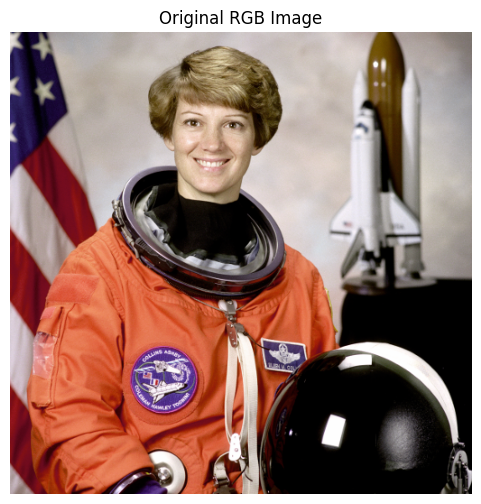

In [5]:
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("Original RGB Image")
plt.axis("off")
plt.show()

## 4. 拆開 RGB channels

一張彩色影像其實就是三張 2D intensity map 疊在一起。

```text
RGB image = R channel + G channel + B channel
```

每個 channel 仍然可以視為一張灰階圖，只是它代表的是某個顏色成分的強度。

In [6]:
r_channel = image_rgb[:, :, 0]
g_channel = image_rgb[:, :, 1]
b_channel = image_rgb[:, :, 2]

inspect_image("R channel", r_channel)
print()
inspect_image("G channel", g_channel)
print()
inspect_image("B channel", b_channel)

影像名稱 : R channel
資料型別 : <class 'numpy.ndarray'>
Shape    : (512, 512)
Dtype    : uint8
Min/Max  : 0 / 255

影像名稱 : G channel
資料型別 : <class 'numpy.ndarray'>
Shape    : (512, 512)
Dtype    : uint8
Min/Max  : 0 / 255

影像名稱 : B channel
資料型別 : <class 'numpy.ndarray'>
Shape    : (512, 512)
Dtype    : uint8
Min/Max  : 0 / 255


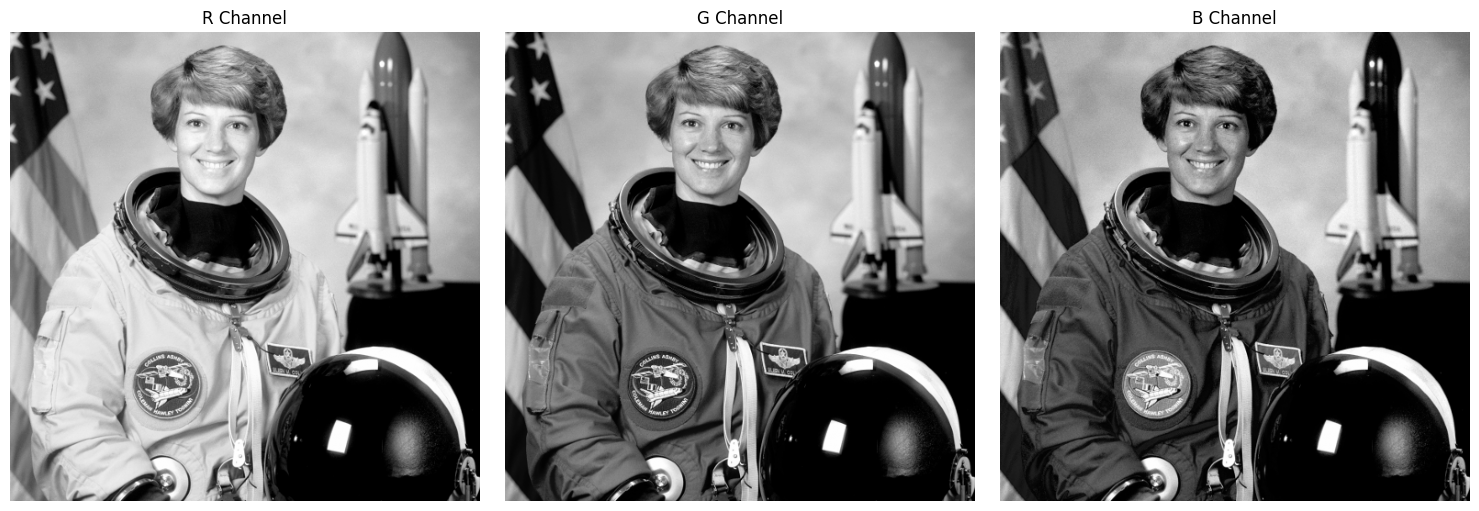

In [7]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(r_channel, cmap="gray", vmin=0, vmax=255)
plt.title("R Channel")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(g_channel, cmap="gray", vmin=0, vmax=255)
plt.title("G Channel")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(b_channel, cmap="gray", vmin=0, vmax=255)
plt.title("B Channel")
plt.axis("off")

plt.tight_layout()
plt.show()

## 5. RGB 轉灰階

灰階轉換就是把三個顏色數值壓縮成一個亮度值。

```text
RGB pixel  = [R, G, B]
Gray pixel = 一個亮度值
```

代價很明確：灰階化會讓問題變簡單，但也會丟掉顏色資訊。當任務主要依靠結構、邊緣、形狀或亮度，而不是顏色時，灰階就很適合。

In [8]:
# 輸入影像是 RGB，所以使用 COLOR_RGB2GRAY。
image_gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

inspect_image("image_gray", image_gray)

影像名稱 : image_gray
資料型別 : <class 'numpy.ndarray'>
Shape    : (512, 512)
Dtype    : uint8
Min/Max  : 0 / 255


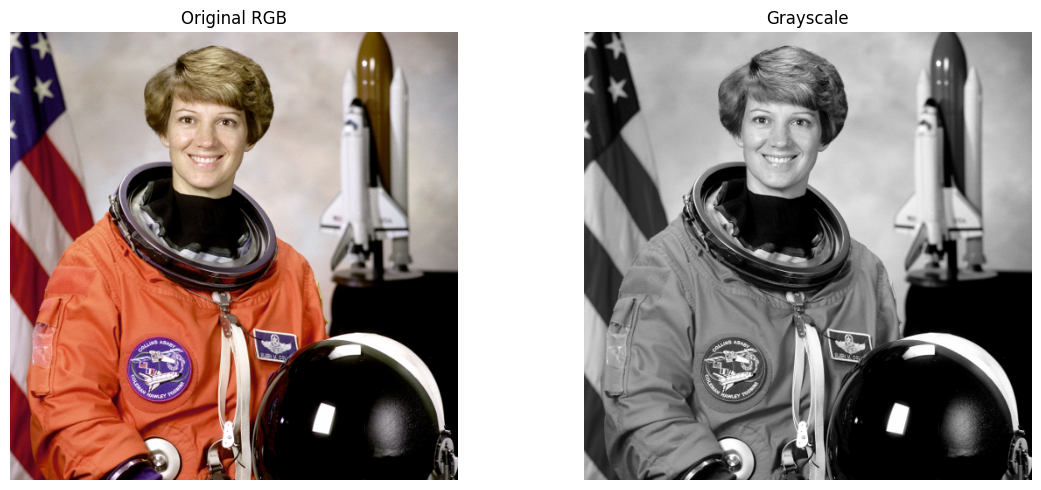

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_gray, cmap="gray", vmin=0, vmax=255)
plt.title("Grayscale")
plt.axis("off")

plt.tight_layout()
plt.show()

## 6. 灰階顯示的細節

顯示 2D 灰階影像時，建議明確指定 `cmap="gray"`。

如果沒有指定，Matplotlib 可能會用偽彩色 colormap 顯示。資料本身沒有錯，但視覺解讀會被誤導。

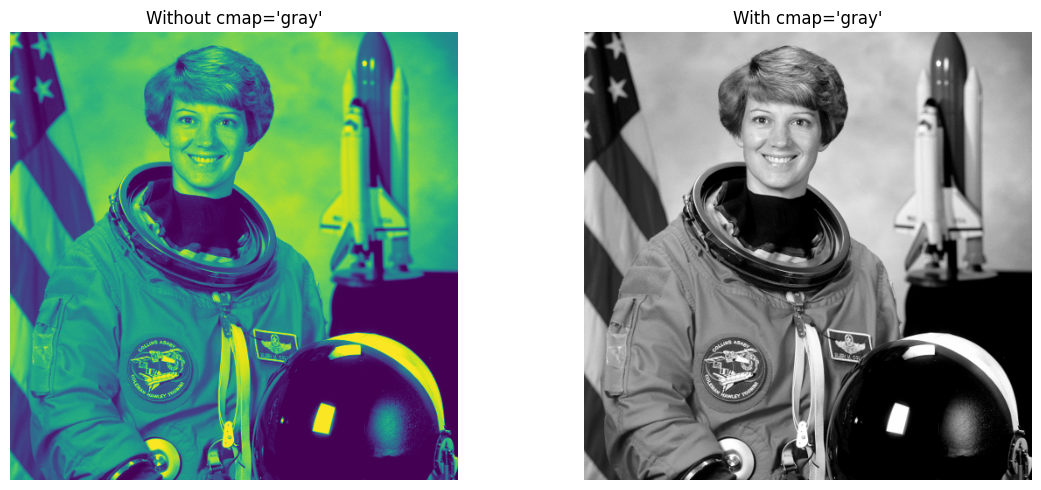

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_gray)
plt.title("Without cmap='gray'")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_gray, cmap="gray", vmin=0, vmax=255)
plt.title("With cmap='gray'")
plt.axis("off")

plt.tight_layout()
plt.show()

## 7. RGB 與 BGR

OpenCV 使用 `cv2.imread()` 讀取彩色影像時，channel 順序通常是 BGR。

Matplotlib 顯示彩色影像時，預期的是 RGB。

所以如果把 OpenCV 讀進來的 BGR 影像直接丟給 Matplotlib 顯示，顏色會錯。

實務規則：

```text
OpenCV 讀進來是 BGR
Matplotlib 顯示需要 RGB
顯示前要轉換
```

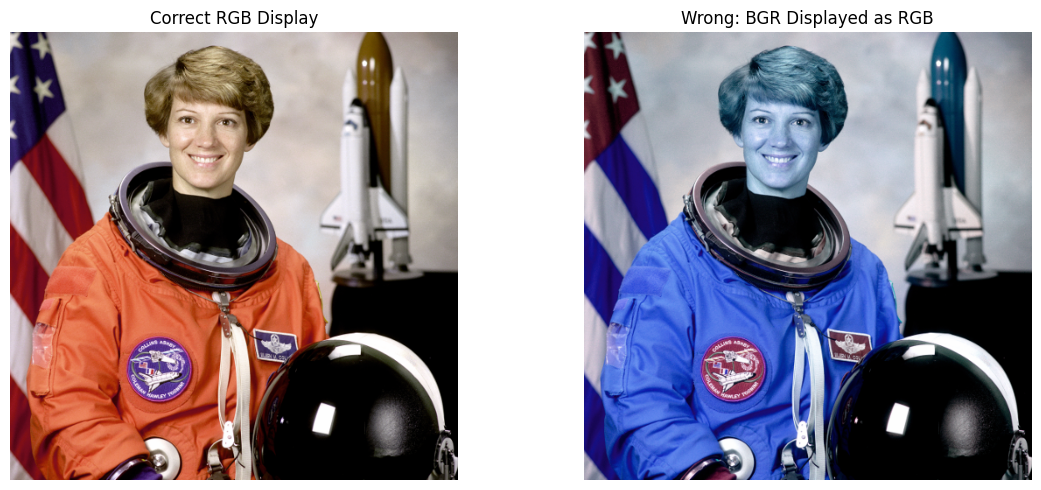

In [11]:
# 模擬 OpenCV 讀進來的 BGR 影像。
image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Correct RGB Display")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_bgr)
plt.title("Wrong: BGR Displayed as RGB")
plt.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_rgb_bgr_display_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

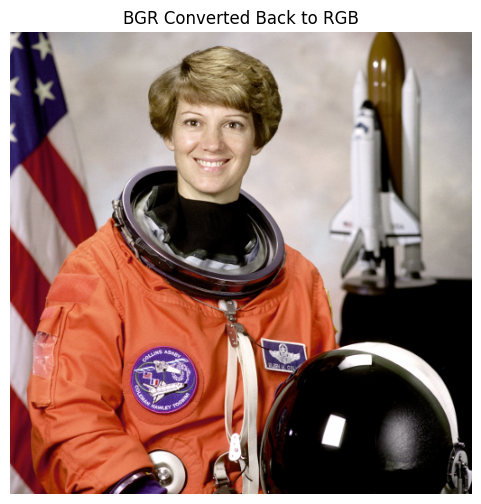

In [12]:
# 正確做法：OpenCV 的 BGR 影像要先轉回 RGB，再用 Matplotlib 顯示。
image_bgr_to_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(image_bgr_to_rgb)
plt.title("BGR Converted Back to RGB")
plt.axis("off")
plt.show()

## 8. RGB 轉 HSV

HSV 把顏色拆成三個問題：

| Channel | 意義 |
|---|---|
| H | 是什麼顏色 |
| S | 顏色有多強 |
| V | 有多亮 |

這就是 HSV 常用在簡單顏色分割的原因。有時候有用的資訊不會平均分散在 RGB 三個 channel 裡，而是會很明顯出現在 Saturation 或 Value 裡。

In [13]:
image_hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)

h_channel = image_hsv[:, :, 0]
s_channel = image_hsv[:, :, 1]
v_channel = image_hsv[:, :, 2]

inspect_image("H channel", h_channel)
print()
inspect_image("S channel", s_channel)
print()
inspect_image("V channel", v_channel)

影像名稱 : H channel
資料型別 : <class 'numpy.ndarray'>
Shape    : (512, 512)
Dtype    : uint8
Min/Max  : 0 / 179

影像名稱 : S channel
資料型別 : <class 'numpy.ndarray'>
Shape    : (512, 512)
Dtype    : uint8
Min/Max  : 0 / 255

影像名稱 : V channel
資料型別 : <class 'numpy.ndarray'>
Shape    : (512, 512)
Dtype    : uint8
Min/Max  : 0 / 255


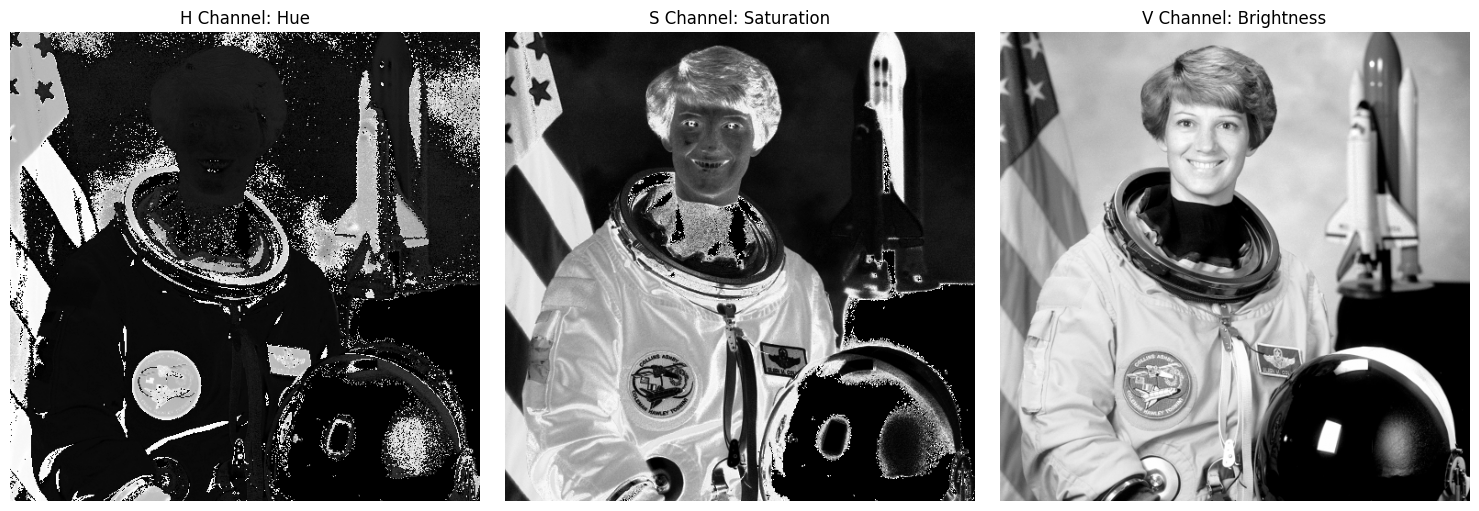

In [14]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(h_channel, cmap="gray")
plt.title("H Channel: Hue")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(s_channel, cmap="gray", vmin=0, vmax=255)
plt.title("S Channel: Saturation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(v_channel, cmap="gray", vmin=0, vmax=255)
plt.title("V Channel: Brightness")
plt.axis("off")

plt.tight_layout()
plt.show()

## 9. 從 Saturation 建立簡單 mask

Mask 本質上就是一張標記哪些 pixels 要保留的圖。

這裡用 Saturation channel 建立 mask：

```text
高 saturation = 顏色很強
低 saturation = 接近灰、白、黑
```

這不是完整偵測系統，只是在示範很多傳統影像流程的基本邏輯：選一個有用的 channel，做 threshold，再把 mask 套回原圖。

In [15]:
saturation_threshold = 80
saturation_mask = (s_channel > saturation_threshold).astype(np.uint8) * 255

inspect_image("saturation_mask", saturation_mask)

影像名稱 : saturation_mask
資料型別 : <class 'numpy.ndarray'>
Shape    : (512, 512)
Dtype    : uint8
Min/Max  : 0 / 255


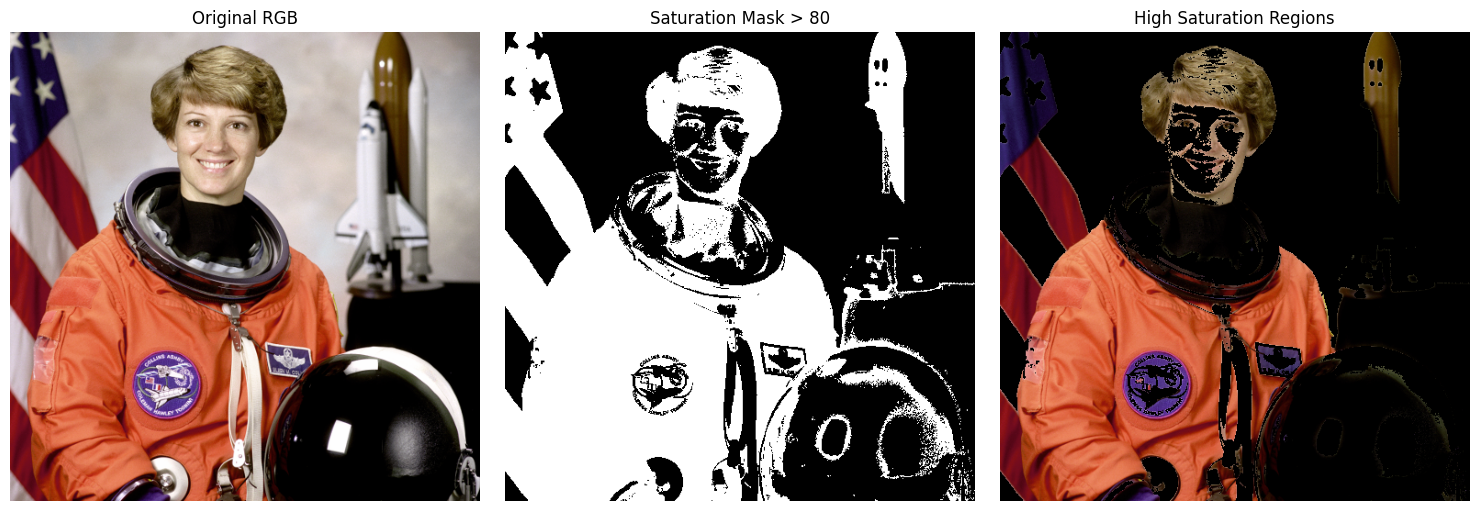

In [16]:
segmented_rgb = cv2.bitwise_and(image_rgb, image_rgb, mask=saturation_mask)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(saturation_mask, cmap="gray", vmin=0, vmax=255)
plt.title(f"Saturation Mask > {saturation_threshold}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(segmented_rgb)
plt.title("High Saturation Regions")
plt.axis("off")

plt.tight_layout()
plt.show()

## 10. 保存中間結果

保存中間影像不是裝飾，而是除錯。

當最終結果出錯時，中間結果可以幫助判斷到底是哪一步壞掉：讀圖、轉換、mask，還是後處理。

In [17]:
# cv2.imwrite 儲存彩色影像時預期 BGR。
# 因此 RGB 影像要先轉成 BGR 再用 OpenCV 存檔。
cv2.imwrite(str(OUTPUT_DIR / "01_original_rgb.png"), cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUTPUT_DIR / "02_grayscale.png"), image_gray)
cv2.imwrite(str(OUTPUT_DIR / "03_saturation_mask.png"), saturation_mask)
cv2.imwrite(str(OUTPUT_DIR / "04_high_saturation_regions.png"), cv2.cvtColor(segmented_rgb, cv2.COLOR_RGB2BGR))

print("已儲存輸出檔案：")
for path in sorted(OUTPUT_DIR.glob("*.png")):
    print(path)

已儲存輸出檔案：
outputs/01_image_basics/01_original_rgb.png
outputs/01_image_basics/02_grayscale.png
outputs/01_image_basics/03_saturation_mask.png
outputs/01_image_basics/04_high_saturation_regions.png
outputs/01_image_basics/05_rgb_bgr_display_comparison.png


## 11. 工程筆記

- 影像不是神秘物件，它就是有 shape、dtype、value range 的陣列。
- 灰階化會簡化問題，但也會移除顏色資訊。
- RGB / BGR 錯誤不一定會讓程式報錯，但會讓結果默默變錯。
- Mask 本質上就是 pixel-level 的保留 / 移除決策。
- 中間結果讓影像處理流程可以被檢查與除錯。

實務習慣應該是：

```text
檢查 → 謹慎轉換 → 正確顯示 → 保存中間結果
```

## 12. 下一步

下一份 notebook：

```text
../02_filtering_and_denoising/filtering_and_denoising.ipynb
```

中文版：

```text
../02_filtering_and_denoising/filtering_and_denoising_zh.ipynb
```